# Using the data in the RO-Crate
The processed RO-Crates contain a new directory with provenance data.
The file contain a provenance directory with the PROV-O graph (JSON-LD and Turtle) and one detailed metadata file for each dataset (JSON-LD), The individual JSON-LD files contain interoperability and discovery metadata.

```
exp_crate/
|-- datasets/
|   |-- ds_001.xxx
|   `-- ...
|-- provenance/
|   |-- galaxy_run_prov.jsonld
|   |-- galaxy_run_prov.ttl
|   |-- dataset_ds_001.xxx.jsonld
|   `-- ...
|-- workflow/
|--ro-crate-metadata.json
...
```
We can extract and use metadata to access the data directly.

## Example 1 Reproduce Figure 4A - XANES Analysis
The first set of XAS results in the paper are in [Figure 4](https://pubs.rsc.org/image/article/2018/fd/c7fd00221a/c7fd00221a-f4_hi-res.gif)

To reproduce this image we need to:
- Identify the XANES data used (SnO2, Air, Ar, H2 and Sn foil)
- Plot normalised flattened mE of the spectra on the range 29190 – 29450 
- Plot first derivate of the spectra on the range 29190 – 29215

1. read RO-Crate
2. get summary of datasets
3. filter using criteria (element, edge, processing level, data type)
4. use RO-Crate library to get the data into Larch
5. use matplotlib to plot the data

## 1.1 Reading the RO-Crate
The code below shows how to get the RO-Crate provenance metadata and shows the PROVO graph resulting from it.

In [1]:
# RO-Crate access
from rocrate.rocrate import ROCrate
# Directory and file management
from pathlib import Path

# defined functions to get data from RO-Crate
from read_provenance import *

# "FeS2-Analysis.rocrate.prov.zip" FeS2 example modified
# "Paper_1_Pt3Sn.rocrate.prov.zip" paper 1 modified
file_name = "Paper_1_Pt3Sn.rocrate.prov.zip"

file_path = Path("./result_roc", file_name)

# get the PROV-O graph from the RO-Crate
roc_prov = get_roc_provenance(file_path)

#plan_dot = draw_prov_only(roc_prov)
#display(plan_dot)

#get datasets provenance from the roc graph
datasets_provenance = get_datasets_prov(roc_prov)
display(HTML(datasets_provenance.to_html().replace("\\n","<br>")))

C:\Users\scman1\AppData\Roaming\Python\Python39\site-packages\rocrate\vocabs.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


,Step,Activity,Tool,Dataset,Inputs
0,/step/0,fetch data from history,DATA_FETCH,Sn foil.prj,None
1,/step/10,fetch data from history,DATA_FETCH,263933_PtSn_OCH_5.dat,None
2,/step/10,fetch data from history,DATA_FETCH,263931_PtSn_OCH_3.dat,None
3,/step/10,fetch data from history,DATA_FETCH,263930_PtSn_OCH_2.dat,None
4,/step/10,fetch data from history,DATA_FETCH,263932_PtSn_OCH_4.dat,None
5,/step/10,fetch data from history,DATA_FETCH,263929_PtSn_OCH_1.dat,None
6,/step/10,fetch data from history,DATA_FETCH,263934_PtSn_OCH_6.dat,None
7,/step/12,fetch data from history,DATA_FETCH,263831_PtSn_OCH_8.dat,None
8,/step/12,fetch data from history,DATA_FETCH,263824_PtSn_OCH_1.dat,None
9,/step/12,fetch data from history,DATA_FETCH,263829_PtSn_OCH_6.dat,None


## 1.2 Get datasets metadata
Having access to the provenance and dataset context metadata allows rapid access to the data.
For instance the code below shows how to summarise the Types and Formats of the dataset files in the RO-Crate.

In [2]:
crate = ROCrate(file_path)
data_entities = []
for e in crate.get_entities():
    if "provenance/data" in e.id:
        #print(e.id, e.type)
        data_entities.append(e.id)
        
print (f"There are {len(data_entities)} datasets in {file_name}\n")

from collections import Counter
from rdflib import RDF, Namespace

PROV = Namespace("http://www.w3.org/ns/prov#")
entities = set(roc_prov.subjects(RDF.type, PROV.Entity))

types = Counter()
formats = Counter()
subjects = Counter()
for e in entities:
    # entity types
    for t in roc_prov.objects(e, RDF.type):
        if t != PROV.Entity:
            types[str(t).split("/")[-1]] += 1

    # file formats
    for f in roc_prov.objects(e, DCTERMS.format):
        formats[str(f)] += 1

print("*"*5,"Provenance metadata","*"*5)

print("\nTypes")
for k, v in types.most_common():
    print(f"{k}: {v}")

print("\nFormats")
for k, v in formats.most_common():
    print(f"{k}: {v}")

# sumarisig datasets using context metadata
# look up graphs
panet_graph = Graph()
sweet_graph = Graph()
panet_graph.parse("resources/panent_fragment.ttl")
sweet_graph.parse("resources/sweet-pl.ttl") 


def first_object(graph, predicate, default=""):
    return next(graph.objects(None, predicate), default)

FIELD_MAP = {
    "dataset": SKOS.prefLabel,
    "file_type": DCTERMS.format,
    "location": SCHEMA.id,
    "element": CDIF4XAS.element,
    "edge": CDIF4XAS.edge,
    "e0": CDIF4XAS.e0,
}

ds_data = {}

for an_ent in data_entities:
    g = Graph()
    # load dataset data into a graph
    g.parse(
        data=json.dumps(get_roc_json_part(file_path, an_ent)),
        format="json-ld",
        publicID="/"
    )
    # get the data from graph the triples
    ent_data = {
        key: first_object(g, pred)
        for key, pred in FIELD_MAP.items()
    }
    # Get PANET and SWEET data as readable labels
    for subject in g.objects(None, DCTERMS.subject):
        target_graph, pred, key = (
            (panet_graph, SKOS.altLabel, "data_type")
            if str(PANET) in str(subject)
            else (sweet_graph, SKOS.prefLabel, "proc_level")
        )
        ent_data[key] = next(
            target_graph.objects(subject, pred),
            ""
        )
    ds_data[an_ent] = ent_data

df_datasets = pd.DataFrame.from_dict(ds_data, orient="index")

summary = {
    "element": df_datasets["element"].value_counts(),
    "file_type": df_datasets["file_type"].value_counts(),
    "proc_level": df_datasets["proc_level"].value_counts(),
    "data_type": df_datasets["data_type"].value_counts(),
}

print("*"*5,"Context metadata","*"*5)

for category, counts in summary.items():
    print(f"\n{category.upper()}")
    print(counts)

display(HTML(df_datasets.to_html().replace("\\n","<br>")))

There are 90 datasets in Paper_1_Pt3Sn.rocrate.prov.zip

***** Provenance metadata *****

Types
CDIF-PROV#Dataset: 90
MediaObject: 90
CDIF-PROV#DataProduct: 18

Formats
text/plain: 42
image/png: 18
application/vnd.demeter.athena: 12
text/csv: 6
application/zip: 5
chemical/x-feff-input: 4
chemical/x-cif: 3
***** Context metadata *****

ELEMENT
Sn      38
Pt      32
        18
None     2
Name: element, dtype: int64

FILE_TYPE
text/plain                        42
image/png                         18
application/vnd.demeter.athena    12
text/csv                           6
application/zip                    5
chemical/x-feff-input              4
chemical/x-cif                     3
Name: file_type, dtype: int64

PROC_LEVEL
Raw          38
Derived      22
Product      18
Processed    12
Name: proc_level, dtype: int64

DATA_TYPE
XAS                         40
obtain crystal structure    18
EXAFS                       12
NEXAFS                      10
Name: data_type, dtype: int64


,dataset,file_type,location,element,edge,e0,data_type,proc_level
provenance/dataset_b9b199e627b0df6d.jsonld,Sn foil.prj,application/vnd.demeter.athena,datasets/Sn_foil.prj_b9b199e627b0df6d.prj,Sn,K,29200.0,XAS,Processed
provenance/dataset_c1b1e33af4bbfb98.jsonld,263929_PtSn_OCH_1.dat,text/plain,datasets/263929_PtSn_OCH_1.dat_c1b1e33af4bbfb98.tabular,Pt,L3,11561.2,XAS,Raw
provenance/dataset_2dce3cba98f791fe.jsonld,263930_PtSn_OCH_2.dat,text/plain,datasets/263930_PtSn_OCH_2.dat_2dce3cba98f791fe.tabular,Pt,L3,11561.2,XAS,Raw
provenance/dataset_c289466c92d2c272.jsonld,263931_PtSn_OCH_3.dat,text/plain,datasets/263931_PtSn_OCH_3.dat_c289466c92d2c272.tabular,Pt,L3,11561.2,XAS,Raw
provenance/dataset_8392e1ce86b3f444.jsonld,263932_PtSn_OCH_4.dat,text/plain,datasets/263932_PtSn_OCH_4.dat_8392e1ce86b3f444.tabular,Pt,L3,11561.2,XAS,Raw
provenance/dataset_4abf214e1e3925e6.jsonld,263933_PtSn_OCH_5.dat,text/plain,datasets/263933_PtSn_OCH_5.dat_4abf214e1e3925e6.tabular,Pt,L3,11561.2,XAS,Raw
provenance/dataset_5fa221e2b289fef6.jsonld,263934_PtSn_OCH_6.dat,text/plain,datasets/263934_PtSn_OCH_6.dat_5fa221e2b289fef6.tabular,Pt,L3,11561.2,XAS,Raw
provenance/dataset_e3402f59457e3fa3.jsonld,263824_PtSn_OCH_1.dat,text/plain,datasets/263824_PtSn_OCH_1.dat_e3402f59457e3fa3.tabular,Pt,L3,11561.2,XAS,Raw
provenance/dataset_0058e687a1b46bf1.jsonld,263825_PtSn_OCH_2.dat,text/plain,datasets/263825_PtSn_OCH_2.dat_0058e687a1b46bf1.tabular,Pt,L3,11561.2,XAS,Raw
provenance/dataset_842f0b51123a144a.jsonld,263826_PtSn_OCH_3.dat,text/plain,datasets/263826_PtSn_OCH_3.dat_842f0b51123a144a.tabular,Pt,L3,11561.2,XAS,Raw


## 1.3 Filter Datasets using metadata

The datasets metadata (in df_datasets above) contains a number of key attributes—such as element, data type, processing level, and file type—that can be used to filter the 90 datasets and identify the specific files required.

The code below does this filtering and returns the specific datasets to use. The attributes we are looking for are: Element Sn, Edge K, Processed, XANES

In [3]:
ds_selected = df_datasets[
    (df_datasets["element"] == Literal("Sn")) &
    (df_datasets["edge"] == Literal("K")) &
    (df_datasets["file_type"] == Literal("application/vnd.demeter.athena")) &
    (df_datasets["data_type"].isin([Literal("NEXAFS"),Literal("XAS")] )) &
    (df_datasets["proc_level"].isin([Literal('Processed', lang='en')] ))
    ]

ds_selected

,dataset,file_type,location,element,edge,e0,data_type,proc_level
provenance/dataset_b9b199e627b0df6d.jsonld,Sn foil.prj,application/vnd.demeter.athena,datasets/Sn_foil.prj_b9b199e627b0df6d.prj,Sn,K,29200.0,XAS,Processed
provenance/dataset_48b3093bef30842b.jsonld,SnO2 0.9 2.6-13.5 gbkg.prj,application/vnd.demeter.athena,datasets/SnO2_0.9_2.6-13.5_gbkg.prj_48b3093bef...,Sn,K,29205.999999999996,XAS,Processed
provenance/dataset_c29a44dc6314ba0e.jsonld,"Athena project SnK H2 under H2 data 9, data 8,...",application/vnd.demeter.athena,datasets/Athena_project_SnK_H2_under_H2_data_9...,Sn,K,29200.000000000004,NEXAFS,Processed
provenance/dataset_36c7e5f712ef2c28.jsonld,"Athena project SnK H2 data 13, data 12, and ot...",application/vnd.demeter.athena,"datasets/Athena_project_SnK_H2_data_13,_data_1...",Sn,K,29204.5,NEXAFS,Processed
provenance/dataset_3ad7603d647b0250.jsonld,"Athena project SnK Ar data 17, data 16, and ot...",application/vnd.demeter.athena,"datasets/Athena_project_SnK_Ar_data_17,_data_1...",Sn,K,29204.5,NEXAFS,Processed
provenance/dataset_dd9f988a14463c37.jsonld,"Athena project SnK Air data 20, data 19, and d...",application/vnd.demeter.athena,"datasets/Athena_project_SnK_Air_data_20,_data_...",Sn,K,29204.5,NEXAFS,Processed


The filtered data (ds_selected) returned 6 datasets, but we only need 5. Looking at the names we can see that the extra dataset is "Athena project SnK H2 under H2 data 9, data 8, and others". The final list is:

|Tag|Dataset attributes|dataset name|dataset id|
|:--|:--|:--|:-- |
|SnO$_2$ |Element Sn, Edge K, Processed, XANES|Athena project SnO2 data 2         |atasets/Athena_project_SnO2_data_2_849d77a821f43675.prj|
|SnK air |Element Sn, Edge K, Processed, XANES|Athena project SnK Air data 20, ...|datasets/Athena_project_SnK_Air_data_20,_data_19,_and_data_18_dd9f988a14463c37.prj|
|SnK Ar  |Element Sn, Edge K, Processed, XANES|Athena project SnK Ar data 17, ... |datasets/Athena_project_SnK_Ar_data_17,_data_16,_and_others_3ad7603d647b0250.prj|
|SnK H2  |Element Sn, Edge K, Processed, XANES|Athena project SnK H2 data 13, ... |datasets/Athena_project_SnK_H2_data_13,_data_12,_and_others_36c7e5f712ef2c28.prj|
|SnK Foil|Element Sn, Edge K, Processed, XANES|Foil Athena project Sn Foil data 1 |datasets/Athena_project_Sn_Foil_data_1_9fba01839dc61c03.prj|

The cell below removes the third dataset which is not needed

In [4]:
ds_selected=ds_selected.drop("provenance/dataset_c29a44dc6314ba0e.jsonld")
ds_selected

,dataset,file_type,location,element,edge,e0,data_type,proc_level
provenance/dataset_b9b199e627b0df6d.jsonld,Sn foil.prj,application/vnd.demeter.athena,datasets/Sn_foil.prj_b9b199e627b0df6d.prj,Sn,K,29200.0,XAS,Processed
provenance/dataset_48b3093bef30842b.jsonld,SnO2 0.9 2.6-13.5 gbkg.prj,application/vnd.demeter.athena,datasets/SnO2_0.9_2.6-13.5_gbkg.prj_48b3093bef...,Sn,K,29205.999999999996,XAS,Processed
provenance/dataset_36c7e5f712ef2c28.jsonld,"Athena project SnK H2 data 13, data 12, and ot...",application/vnd.demeter.athena,"datasets/Athena_project_SnK_H2_data_13,_data_1...",Sn,K,29204.5,NEXAFS,Processed
provenance/dataset_3ad7603d647b0250.jsonld,"Athena project SnK Ar data 17, data 16, and ot...",application/vnd.demeter.athena,"datasets/Athena_project_SnK_Ar_data_17,_data_1...",Sn,K,29204.5,NEXAFS,Processed
provenance/dataset_dd9f988a14463c37.jsonld,"Athena project SnK Air data 20, data 19, and d...",application/vnd.demeter.athena,"datasets/Athena_project_SnK_Air_data_20,_data_...",Sn,K,29204.5,NEXAFS,Processed


## 1.4 Use RO-Crate library to get the data into Larch
In this section we extract the selected files and load the data into larch before passing it to the plotting functions.

Larch cannot read Athena data from a stream; it must unpack the file locally. 

The code below reads and saves the required data, and then Larch reads the data.

In [5]:
# Library with the functions that can handle athena files
# normalisation, merging, re-binning, LCF
# and visualisation (plotting)# Library with the functions that rplicate those provided by athena
# normalisation, merging, re-binning, LCF
# and visualisation (plotting)
import lib.larch_data_reader as larch_reader  
tags = {"Sn_foil":"Sn Foil", "SnO2": "SnO2", 
        "SnK_H2":"H2", "SnK_Air":"Air", 
        "SnK_Ar":"Ar"}  

from larch import Interpreter
lrch_session = Interpreter()

#################################
# Extracting Data from RO-Crate #
#################################
work_files = {}
for df_id in ds_selected["location"]:
    working_dir = "./larch_processing"
    working_prj_name = df_id.split("/")[1]
    Path(working_dir).mkdir(parents=True, exist_ok=True)
    working_path = Path(working_dir, working_prj_name)
    for a_tag in tags:
        if a_tag in working_prj_name:
            work_files[a_tag] = working_path
    print(f"extracting {df_id}")
    # Larch cannot read Athena data from a stream; it must unpack the file locally.
    wfile_data = get_file_from_rocratezip(file_path, str(df_id)).read()
    with open(working_path, "wb") as f:
        f.write(wfile_data)
        
#################################
#   Reading data into Larch     #
#################################
project_groups = {}

for a_tag in work_files:
    project_groups[a_tag] = larch_reader.read_project(work_files[a_tag])

plot_groups={}
for a_pg in project_groups:
    if a_pg == "Sn_foil":
        plot_groups[tags[a_pg]] = larch_reader.get_group(project_groups[a_pg], 'merge')        
    elif a_pg == "SnO2":
        plot_groups[tags[a_pg]] = larch_reader.get_group(project_groups[a_pg], "SnO2_0_9_2_6_13_5_0_8_1_0_with_theory")#'SnO2_0_9')
        plot_groups[tags[a_pg]].name = tags[a_pg]
    else:
        plot_groups[tags[a_pg]] = larch_reader.get_group(project_groups[a_pg], next(iter(project_groups[a_pg])))
    plot_groups[tags[a_pg]].filename = tags[a_pg]

# results in the paper are recalibrated to 29204
recalibrate_e0_to = 29204

for a_sample in plot_groups:
    if a_sample != "Sn Foil"
    plot_groups[a_sample] = larch_reader.recalibrate_energy(plot_groups[a_sample], recalibrate_e0_to)

No conda env active, defaulting to base
extracting datasets/Sn_foil.prj_b9b199e627b0df6d.prj
extracting datasets/SnO2_0.9_2.6-13.5_gbkg.prj_48b3093bef30842b.prj
extracting datasets/Athena_project_SnK_H2_data_13,_data_12,_and_others_36c7e5f712ef2c28.prj
extracting datasets/Athena_project_SnK_Ar_data_17,_data_16,_and_others_3ad7603d647b0250.prj
extracting datasets/Athena_project_SnK_Air_data_20,_data_19,_and_data_18_dd9f988a14463c37.prj


## 5. use matplotlib to plot the data
The code cell below:
- reads the RO-Crate and gets all dataset provenance files in a list
- loads the first provenance file
- shows its contents as JSON

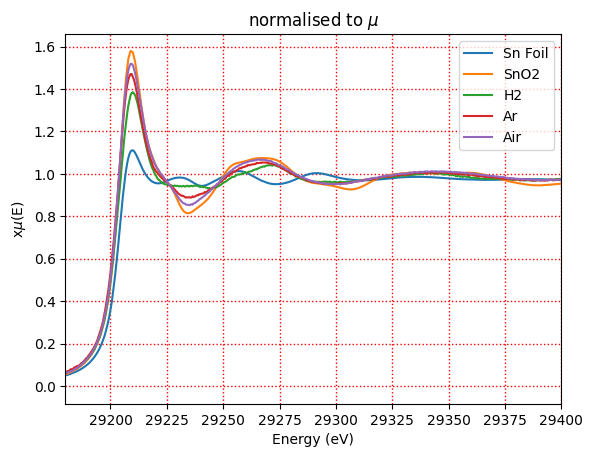

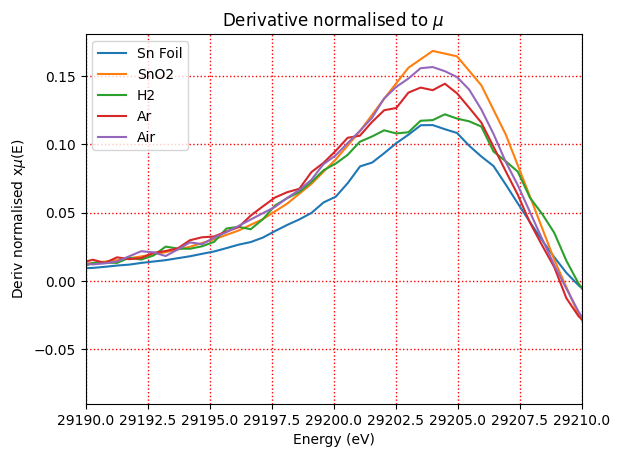

In [6]:
#plotting library
import matplotlib.pyplot as plt
# inline: shows plot in notebook
# tk: shows plot in popup
#%matplotlib inline 

include_groups = ["Air", "Ar", "H2", "Sn Foil", "SnO2"]
for a_sample in plot_groups:
    if plot_groups[a_sample].filename in include_groups:
        plt = larch_reader.plot_normalised(plot_groups[a_sample])
    
plt.xlim([29180, 29400])
plt.show()

for a_sample in plot_groups:
    if plot_groups[a_sample].filename in include_groups:
        plt = larch_reader.plot_derivative(plot_groups[a_sample])
    
plt.xlim([29190, 29210])
plt.show()
